## BMF coherence length vs wavelength

`BMF_peak_thickness.ipynb` の mock `meta` を流用して、BMF の各 `dij` 配置についてコヒーレンス長 `L_c = \pi / \Delta k` の波長依存を確認するノートブックです。

In [1]:
import copy
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "test_codes":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
from shg_analysis import SHGDataAnalysis
from fitting_strategies.bechthold1977 import Bechthold1977WedgeStrategy

### Mock metadata for each BMF `dij`

既存ノートに合わせて、各配置だけを切り替えた簡単な mock `meta` を使います。

In [4]:
mock_data = pd.DataFrame({"position": [0.0]})

meta_base = {
    "sample": "BMF_mock",
    "material": "BaMgF4",
    "method": "wedge",
    "wavelength_nm": 1064.0,
    "ref_ch": 1,
    "sig_ch": 2,
    "repetition": "1000Hz",
    "operator": "user",
    "notes": "",
    "start": 13.0,
    "end": 21.0,
    "step": 0.1,
    "timestamp": "2026-01-08T12:00:00.000000",
    "thickness_info": {
        "wedge_angle_deg": 0.2,
        "t_center_mm": 1.0,
    },
    "beam_r_x": 359.6,
    "beam_r_y": 423.2,
}

meta_configs = {
    "d31": {
        "crystal_orientation": "010",
        "rot/trans_axis": "100",
        "input_polarization": 90.0,
        "detected_polarization": 0.0,
    },
    "d32": {
        "crystal_orientation": "100",
        "rot/trans_axis": "001",
        "input_polarization": 0.0,
        "detected_polarization": 90.0,
    },
    "d33": {
        "crystal_orientation": "010",
        "rot/trans_axis": "100",
        "input_polarization": 0.0,
        "detected_polarization": 0.0,
    },
}

meta_dict = {}
for dij, config in meta_configs.items():
    meta = copy.deepcopy(meta_base)
    meta.update(config)
    meta_dict[dij] = meta

pd.DataFrame(meta_configs).T

,crystal_orientation,rot/trans_axis,input_polarization,detected_polarization
d31,010,100,90.0,0.0
d32,100,001,0.0,90.0
d33,010,100,0.0,0.0


### Wavelength scan

このコードでは `Bechthold1977WedgeStrategy._maker_fringes(..., return_aux=True)` が `Lc = \pi / \Delta k` を返します。  
`crystaldatabase` の屈折率近似は 150 nm 以上で有効なので、SHG の `\lambda/2` も必要になる都合で fundamental は実質 `300 nm` 以上が計算可能です。ここでは `130-1200 nm` を走査し、計算不能域は `NaN` にしています。

In [5]:
def build_strategy(meta):
    analysis = SHGDataAnalysis(mock_input={"meta": meta, "data": mock_data})
    return Bechthold1977WedgeStrategy(analysis)


def coherence_length_mm(strategy, meta, wavelength_nm):
    meta_local = copy.deepcopy(meta)
    meta_local["wavelength_nm"] = float(wavelength_nm)
    try:
        _, aux = strategy._maker_fringes(override={"meta": meta_local}, return_aux=True)
        return float(aux["Lc"])
    except ValueError as exc:
        if "Wavelength out of approximation range" in str(exc):
            return np.nan
        raise


wavelengths_nm = np.linspace(300.0, 1100.0, 800)
strategies = {dij: build_strategy(meta) for dij, meta in meta_dict.items()}

results_df = pd.DataFrame({"wavelength_nm": wavelengths_nm})
for dij, strategy in strategies.items():
    results_df[f"Lc_{dij}_mm"] = [coherence_length_mm(strategy, meta_dict[dij], wl) for wl in wavelengths_nm]

results_df.head()

,wavelength_nm,Lc_d31_mm,Lc_d32_mm,Lc_d33_mm
0,300.000000,0.000518,0.000439,0.000493
1,301.001252,0.000527,0.000445,0.000501
2,302.002503,0.000535,0.000452,0.000509
3,303.003755,0.000544,0.000458,0.000516
4,304.005006,0.000552,0.000464,0.000524


<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
C:\Users\ui\AppData\Local\Temp\ipykernel_32144\2862075660.py:19: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Coherence length $L_c$ ($\mathrm{\mu}$m)", fontsize=ft)


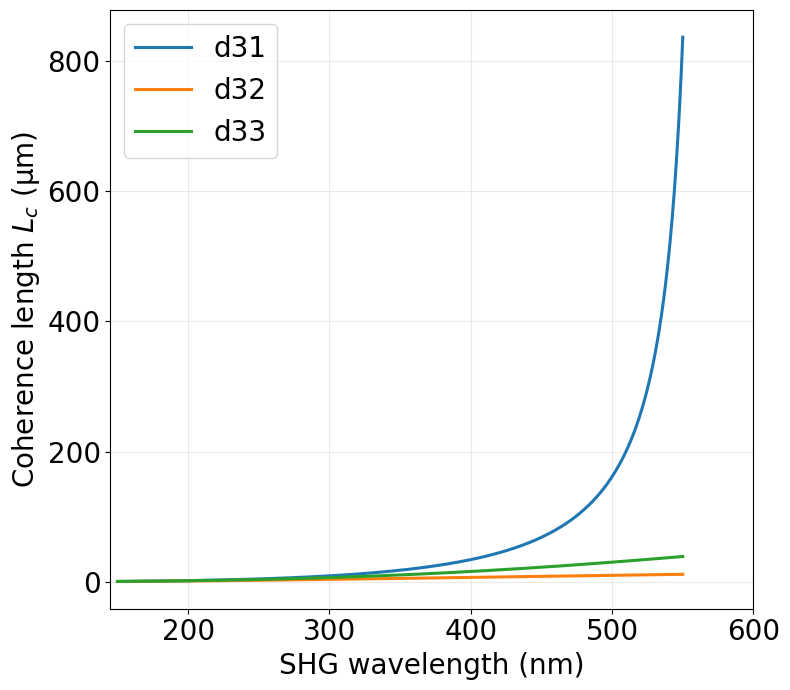

In [11]:
ft = 20
fig, ax = plt.subplots(figsize=(8, 7))

for dij in meta_dict:
    # if dij == "d32":
    #     pass
    # else:
        ax.plot(results_df["wavelength_nm"]/2.0, results_df[f"Lc_{dij}_mm"]*1000, linewidth=2.2, label=dij)

# ax.axvspan(100.0, 150.0, color="0.85", alpha=0.7, label="out of model range")
# ax.axvline(150.0, color="0.35", linestyle="--", linewidth=1.2)

ax.set_xlim(145, 600.0)
# ax.set_ylim(0, 4.5)
# ax.set_yscale("log")
# ax.set_yticks(np.arange(0, 4.5, 1.0))
ax.tick_params(labelsize=ft)
ax.set_xlabel("SHG wavelength (nm)", fontsize=ft)
ax.set_ylabel("Coherence length $L_c$ ($\mathrm{\mu}$m)", fontsize=ft)
# ax.set_title("BMF coherence length vs wavelength", fontsize=ft)
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=ft)
fig.tight_layout()
plt.show()

In [7]:
sample_wavelengths_nm = np.array([300.0, 400.0, 800.0, 1200.0])
summary_rows = []
for wl in sample_wavelengths_nm:
    row = {"wavelength_nm": wl}
    for dij, strategy in strategies.items():
        row[f"Lc_{dij}_mm"] = coherence_length_mm(strategy, meta_dict[dij], wl)
    summary_rows.append(row)

pd.DataFrame(summary_rows)

,wavelength_nm,Lc_d31_mm,Lc_d32_mm,Lc_d33_mm
0,300.0,0.000518,0.000439,0.000493
1,400.0,0.001803,0.001245,0.001600
2,800.0,0.034078,0.006751,0.015828
3,1200.0,-0.558286,0.013054,0.048272
